# Spam Ham Classification using Word2Vec and Average Word2Vec

1. Data Loading
2. Preprocessing for Word2Vec (Lemmatization)
3. Training Word2Vec from scratch using Gensim
4. Average Word2Vec and handling empty sentence vectors
5. Train Test Split
6. Model Training (RandomForestClassifier) and Evaluation

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '../2. Text Pre-Processing/SMSSpam.txt' if os.path.exists('../2. Text Pre-Processing/SMSSpam.txt') else 'smsspamcollection/SMSSpamCollection'
messages = pd.read_csv(path, sep='\t', names=["label", "message"])

In [3]:
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
messages.shape

(5572, 2)

## Data Cleaning and Preprocessing for Word2Vec

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
corpus = []
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
    review = review.lower()
    review = review.split()
    review = [lemmatizer.lemmatize(word) for word in review if word not in stopwords.words('english')]
    corpus.append(review)

In [7]:
corpus[0]

['go',
 'jurong',
 'point',
 'crazy',
 'available',
 'bugis',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amore',
 'wat']

In [8]:
len(corpus)

5572

## Train Word2Vec Model from Scratch using Gensim

In [9]:
import gensim
from gensim.models import Word2Vec

In [10]:
## Training Word2Vec CBOW model
w2v_model = Word2Vec(corpus, vector_size=100, window=5, min_count=2)

In [11]:
len(w2v_model.wv.index_to_key)

3571

In [12]:
## Top 5 most similar words to 'free'
w2v_model.wv.most_similar('free')

[('mobile', 0.999712347984314),
 ('txt', 0.9997044205665588),
 ('reply', 0.9996796250343323),
 ('text', 0.9996768236160278),
 ('week', 0.9996277689933777),
 ('stop', 0.999612033367157),
 ('phone', 0.9995947480201721),
 ('tone', 0.9995810985565186),
 ('win', 0.9995613694190979),
 ('p', 0.9995521306991577)]

In [13]:
w2v_model.wv['free'].shape

(100,)

## Average Word2Vec Implementation

In [14]:
def avg_word2vec(doc):
    words = [word for word in doc if word in w2v_model.wv.index_to_key]
    if len(words) == 0:
        return None
    return np.mean([w2v_model.wv[word] for word in words], axis=0)

In [15]:
type(avg_word2vec(corpus[0]))

numpy.ndarray

In [16]:
avg_word2vec(corpus[0]).shape

(100,)

In [17]:
## Applying Average Word2Vec across the corpus
from tqdm import tqdm
X = []
for i in tqdm(range(len(corpus))):
    X.append(avg_word2vec(corpus[i]))

  0%|          | 0/5572 [00:00<?, ?it/s]

  8%|▊         | 459/5572 [00:00<00:01, 4570.92it/s]

 17%|█▋        | 970/5572 [00:00<00:00, 4833.95it/s]

 26%|██▌       | 1454/5572 [00:00<00:00, 4355.01it/s]

 34%|███▍      | 1895/5572 [00:00<00:00, 4360.43it/s]

 42%|████▏     | 2334/5572 [00:00<00:00, 4232.99it/s]

 50%|████▉     | 2769/5572 [00:00<00:00, 4208.98it/s]

 58%|█████▊    | 3248/5572 [00:00<00:00, 4354.70it/s]

 67%|██████▋   | 3739/5572 [00:00<00:00, 4500.70it/s]

 77%|███████▋  | 4289/5572 [00:00<00:00, 4785.29it/s]

 86%|████████▌ | 4769/5572 [00:01<00:00, 4535.44it/s]

 96%|█████████▌| 5343/5572 [00:01<00:00, 4829.84it/s]

100%|██████████| 5572/5572 [00:01<00:00, 4594.52it/s]

In [18]:
## Handling empty sentences and aligning X and y
X_new = []
valid_indices = []
for i in range(len(X)):
    if type(X[i]) == np.ndarray and len(X[i]) == 100:
        X_new.append(X[i])
        valid_indices.append(i)
X_new = np.array(X_new)

In [19]:
X_new.shape

(5550, 100)

In [20]:
## Aligning target labels y with valid sentences
y = pd.get_dummies(messages['label'], drop_first=True)
y = y.values.flatten()
y = y[valid_indices]

In [21]:
y.shape

(5550,)

## Train Test Split

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.20, random_state=42)

In [23]:
X_train.shape, X_test.shape

((4440, 100), (1110, 100))

## Training RandomForestClassifier on Word2Vec Features

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [25]:
y_pred = rf_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_score(y_test, y_pred)

0.963963963963964

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.96      0.99      0.98       937
        True       0.96      0.80      0.87       173

    accuracy                           0.96      1110
   macro avg       0.96      0.90      0.93      1110
weighted avg       0.96      0.96      0.96      1110



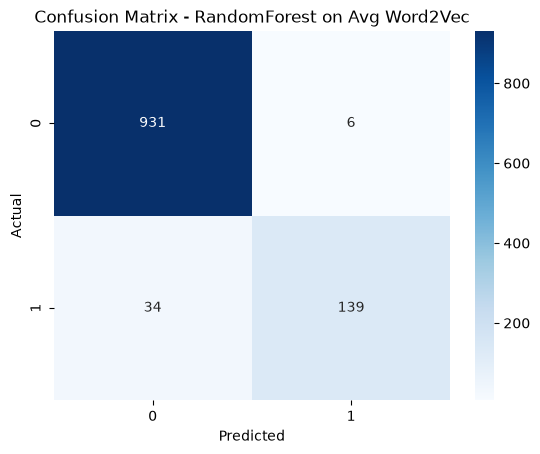

In [28]:
## Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - RandomForest on Avg Word2Vec')
plt.show()